<a href="https://colab.research.google.com/github/Mandara67/DataScience-Project/blob/develop-mandara/Group_6_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

To load data

In [ ]:
df = pd.read_csv("flights_sample_100k_cleaned.csv")

print(df.shape)
df.head()

(100000, 38)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,DAY_OF_WEEK,IS_WEEKEND,ARR_DELAYED,DEP_DELAYED
0,2019-03-01,Allegiant Air,Allegiant Air: G4,G4,20368,1668,PGD,"Punta Gorda, FL",SPI,"Springfield, IL",...,NaN,NaN,NaN,NaN,2019,3,4,0,0,0
1,2021-02-16,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2437,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",...,NaN,NaN,NaN,NaN,2021,2,1,0,0,0
2,2022-04-12,PSA Airlines Inc.,PSA Airlines Inc.: OH,OH,20397,5560,EWN,"New Bern/Morehead/Beaufort, NC",CLT,"Charlotte, NC",...,NaN,NaN,NaN,NaN,2022,4,1,0,0,0
3,2021-10-13,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1944,ABQ,"Albuquerque, NM",DEN,"Denver, CO",...,0.0,0.0,0.0,6.0,2021,10,2,0,1,1
4,2022-06-05,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,3081,PIT,"Pittsburgh, PA",STL,"St. Louis, MO",...,NaN,NaN,NaN,NaN,2022,6,6,1,0,0


Feature Engineering

In [ ]:
# Departure Hour
df['DepHour'] = df['DEP_TIME'] // 100
print("Departure Hours: \n", df['DepHour'])

Departure Hours: 
 0         6.0
1         NaN
2         6.0
3        17.0
4         5.0
         ... 
99995    12.0
99996    11.0
99997    17.0
99998    14.0
99999    14.0
Name: DepHour, Length: 100000, dtype: float64


In [ ]:
# Day of Week
df['FlightDate'] = pd.to_datetime(df['FL_DATE'])
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek # Considering 0 = Monday
print("Day of Week: \n", df['DayOfWeek'])

Day of Week: 
 0        4
1        1
2        1
3        2
4        6
        ..
99995    1
99996    4
99997    2
99998    3
99999    4
Name: DayOfWeek, Length: 100000, dtype: int32


In [ ]:
# Peak vs Non-Peak Hours
def peak_hour(hour):
  if (0 <= hour <= 5) or (8 <= hour <= 20):
    return 1
  return 0
df['PeakHour'] = df['DepHour'].apply(peak_hour)
print("Peak Hours: \n", df['PeakHour'])

Peak Hours: 
 0        0
1        0
2        0
3        1
4        1
        ..
99995    1
99996    1
99997    1
99998    1
99999    1
Name: PeakHour, Length: 100000, dtype: int64


In [ ]:
# Distance Category
def distance_category(distance):
  if distance <= 500:
    return 'Short'
  elif distance <= 1500:
    return 'Medium'
  else:
    return 'Long'

df['DistanceCategory'] = df['DISTANCE'].apply(distance_category)
print("Distance Category: \n", df['DistanceCategory'])

Distance Category: 
 0        Medium
1        Medium
2         Short
3         Short
4        Medium
          ...  
99995     Short
99996      Long
99997     Short
99998    Medium
99999    Medium
Name: DistanceCategory, Length: 100000, dtype: object


In [ ]:
def time_bucket(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 20:
        return 'Evening'
    else:
        return 'Night'

df['TimeBucket'] = df['DepHour'].apply(time_bucket)
print("Time Bucket: \n", df['TimeBucket'])

Time Bucket: 
 0          Morning
1            Night
2          Morning
3          Evening
4          Morning
           ...    
99995    Afternoon
99996      Morning
99997      Evening
99998    Afternoon
99999    Afternoon
Name: TimeBucket, Length: 100000, dtype: object


In [ ]:
df['Weekend'] = df['IS_WEEKEND']

In [ ]:
df['Airline'] = df['AIRLINE']

In [ ]:
airline_delay = df.groupby('Airline')['ARR_DELAYED'].mean().sort_values(ascending=False)

print(airline_delay)

Airline
Allegiant Air                         0.416523
JetBlue Airways                       0.414052
Hawaiian Airlines Inc.                0.399000
Spirit Air Lines                      0.380878
Frontier Airlines Inc.                0.379609
ExpressJet Airlines LLC d/b/a aha!    0.366718
Alaska Airlines Inc.                  0.360069
Southwest Airlines Co.                0.354778
American Airlines Inc.                0.337424
Horizon Air                           0.333333
United Air Lines Inc.                 0.330708
Envoy Air                             0.327691
Mesa Airlines Inc.                    0.322275
PSA Airlines Inc.                     0.316494
SkyWest Airlines Inc.                 0.293561
Delta Air Lines Inc.                  0.286228
Republic Airline                      0.278305
Endeavor Air Inc.                     0.220651
Name: ARR_DELAYED, dtype: float64


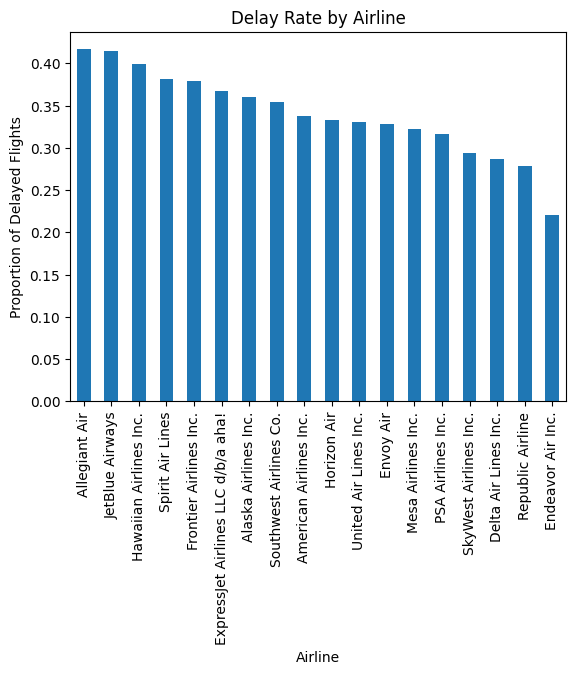

In [ ]:
airline_delay.plot(kind='bar')
plt.title("Delay Rate by Airline")
plt.ylabel("Proportion of Delayed Flights")
plt.show()

In [ ]:
dest_delay = df.groupby('DEST')['ARR_DELAYED'].mean().sort_values(ascending=False)

print(dest_delay.head(10))

DEST
PPG    1.000000
HGR    1.000000
PRC    0.875000
CDB    0.750000
BIH    0.666667
LYH    0.666667
YKM    0.666667
LCK    0.615385
LBF    0.600000
MMH    0.600000
Name: ARR_DELAYED, dtype: float64


In [ ]:
df['Route'] = df['ORIGIN'] + "-" + df['DEST']

In [ ]:
top_origins = df['ORIGIN'].value_counts().head(10).index

df['TopOrigin'] = df['ORIGIN'].apply(lambda x: x if x in top_origins else 'Other')

In [ ]:
top_dests = df['DEST'].value_counts().head(10).index

df['TopDest'] = df['DEST'].apply(lambda x: x if x in top_dests else 'Other')

In [ ]:
route_delay = df.groupby('Route')['ARR_DELAYED'].mean().sort_values(ascending=False)

print(route_delay.head(10))

Route
ABE-FLL    1.0
XNA-DCA    1.0
XNA-EWR    1.0
HDN-ATL    1.0
HDN-SEA    1.0
HGR-MYR    1.0
HGR-SFB    1.0
HNL-ANC    1.0
UIN-ORD    1.0
USA-PGD    1.0
Name: ARR_DELAYED, dtype: float64


In [ ]:
y = df['ARR_DELAYED']
features = ['DepHour', 'DayOfWeek', 'PeakHour', 'DistanceCategory', 'TimeBucket', 'Airline', 'TopOrigin', 'TopDest']
X = df[features]


In [ ]:
X = pd.get_dummies(X, drop_first = True)

In [ ]:
X = X.fillna(X.median())
y = y.loc[X.index]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.67865
Decision Tree Accuracy: 0.6857
Random Forest Accuracy: 0.64795


In [ ]:
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Logistic Regression Confusion Matrix:
[[13339   213]
 [ 6214   234]]

Decision Tree Confusion Matrix:
[[13095   457]
 [ 5829   619]]

Random Forest Confusion Matrix:
[[11092  2460]
 [ 4581  1867]]


In [ ]:
print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_dt))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.68      0.98      0.81     13552
           1       0.52      0.04      0.07      6448

    accuracy                           0.68     20000
   macro avg       0.60      0.51      0.44     20000
weighted avg       0.63      0.68      0.57     20000


Decision Tree Report:
              precision    recall  f1-score   support

           0       0.69      0.97      0.81     13552
           1       0.58      0.10      0.16      6448

    accuracy                           0.69     20000
   macro avg       0.63      0.53      0.49     20000
weighted avg       0.65      0.69      0.60     20000


Random Forest Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.76     13552
           1       0.43      0.29      0.35      6448

    accuracy                           0.65     20000
   macro avg       0.57      0.55      0.55     20000

In [ ]:
importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance_lr.head(20))

                                       Feature  Coefficient
37                                 TopDest_DFW     0.331831
15              Airline_Hawaiian Airlines Inc.     0.222797
17                     Airline_JetBlue Airways     0.215142
8                        Airline_Allegiant Air     0.212442
40                                 TopDest_MCO     0.204919
29                               TopOrigin_LAS     0.199385
2                                     PeakHour     0.198393
26                               TopOrigin_DEN     0.186996
27                               TopOrigin_DFW     0.171501
41                                 TopDest_ORD     0.165349
31                               TopOrigin_ORD     0.128628
36                                 TopDest_DEN     0.118836
38                                 TopDest_LAS     0.116268
42                               TopDest_Other     0.088806
0                                      DepHour     0.082052
6                           TimeBucket_M

In [ ]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_rf.head(20))

                           Feature  Importance
1                        DayOfWeek    0.313552
0                          DepHour    0.233970
42                   TopDest_Other    0.028130
3          DistanceCategory_Medium    0.027369
32                 TopOrigin_Other    0.024404
4           DistanceCategory_Short    0.019215
2                         PeakHour    0.015770
9   Airline_American Airlines Inc.    0.015729
24   Airline_United Air Lines Inc.    0.014817
6               TimeBucket_Morning    0.014301
22  Airline_Southwest Airlines Co.    0.013445
21   Airline_SkyWest Airlines Inc.    0.012191
31                   TopOrigin_ORD    0.011314
39                     TopDest_LAX    0.011248
41                     TopDest_ORD    0.011228
10    Airline_Delta Air Lines Inc.    0.011006
7                 TimeBucket_Night    0.010983
36                     TopDest_DEN    0.010435
30                   TopOrigin_LAX    0.009837
5               TimeBucket_Evening    0.009767


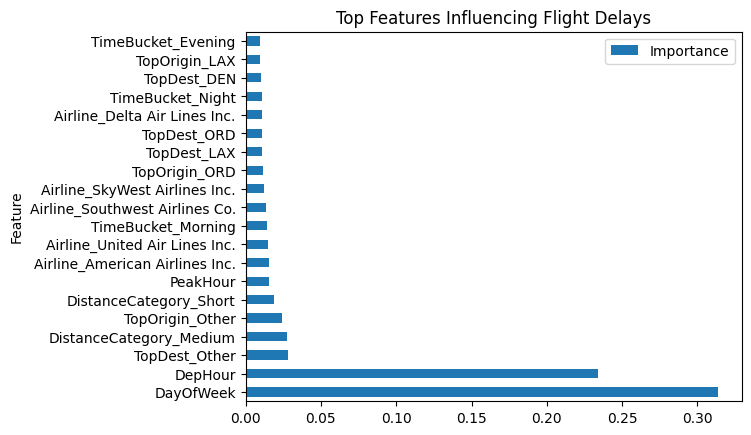

In [ ]:
importance_rf.head(20).plot(
    kind='barh',
    x='Feature',
    y='Importance'
)

plt.title("Top Features Influencing Flight Delays")
plt.show()

In [ ]:
print(importance_rf.head(20))

                           Feature  Importance
1                        DayOfWeek    0.313552
0                          DepHour    0.233970
42                   TopDest_Other    0.028130
3          DistanceCategory_Medium    0.027369
32                 TopOrigin_Other    0.024404
4           DistanceCategory_Short    0.019215
2                         PeakHour    0.015770
9   Airline_American Airlines Inc.    0.015729
24   Airline_United Air Lines Inc.    0.014817
6               TimeBucket_Morning    0.014301
22  Airline_Southwest Airlines Co.    0.013445
21   Airline_SkyWest Airlines Inc.    0.012191
31                   TopOrigin_ORD    0.011314
39                     TopDest_LAX    0.011248
41                     TopDest_ORD    0.011228
10    Airline_Delta Air Lines Inc.    0.011006
7                 TimeBucket_Night    0.010983
36                     TopDest_DEN    0.010435
30                   TopOrigin_LAX    0.009837
5               TimeBucket_Evening    0.009767


In [ ]:
print(df['ARR_DELAYED'].value_counts(normalize=True))

ARR_DELAYED
0    0.67213
1    0.32787
Name: proportion, dtype: float64


In [ ]:
print("Most Delayed Airlines:")
print(airline_delay.head(5))

Most Delayed Airlines:
Airline
Allegiant Air             0.416523
JetBlue Airways           0.414052
Hawaiian Airlines Inc.    0.399000
Spirit Air Lines          0.380878
Frontier Airlines Inc.    0.379609
Name: ARR_DELAYED, dtype: float64


In [ ]:
print("Least Delayed Airlines:")
print(airline_delay.tail(5))

Least Delayed Airlines:
Airline
PSA Airlines Inc.        0.316494
SkyWest Airlines Inc.    0.293561
Delta Air Lines Inc.     0.286228
Republic Airline         0.278305
Endeavor Air Inc.        0.220651
Name: ARR_DELAYED, dtype: float64


In [ ]:
origin_delay = df.groupby('ORIGIN')['ARR_DELAYED'].mean().sort_values(ascending=False)

print(origin_delay.head(10))

ORIGIN
ILG    1.000000
HGR    1.000000
UIN    1.000000
HYA    1.000000
DDC    0.750000
BQN    0.703704
OTH    0.666667
MMH    0.666667
ISN    0.666667
LCK    0.652174
Name: ARR_DELAYED, dtype: float64


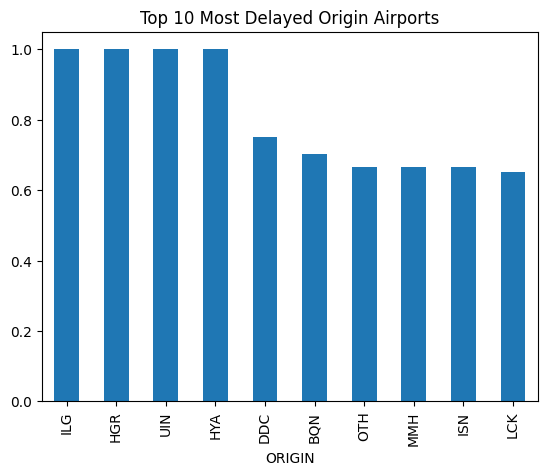

In [ ]:
origin_delay.head(10).plot(kind='bar')
plt.title("Top 10 Most Delayed Origin Airports")
plt.show()